In [1]:
import pandas as pd
import polars as pl
df = pl.read_csv(
    "accepted_2007_to_2018Q4.csv",
    infer_schema_length=10000,
    ignore_errors=True
)

In [2]:
df.head()

id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,…,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
i64,str,f64,f64,f64,str,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,f64,f64,str,f64,f64,f64,str,str,str,str,str,f64,f64,f64
68407277,null,3600.0,3600.0,3600.0,""" 36 months""",13.99,123.03,"""C""","""C4""","""leadman""","""10+ years""","""MORTGAGE""",55000.0,"""Not Verified""","""Dec-2015""","""Fully Paid""","""n""","""https://lendingclub.com/browse…",null,"""debt_consolidation""","""Debt consolidation""","""190xx""","""PA""",5.91,0.0,"""Aug-2003""",675.0,679.0,1.0,30.0,null,7.0,0.0,2765.0,29.7,13.0,…,13734.0,null,null,null,null,null,null,null,null,null,null,null,null,null,"""N""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Cash""","""N""",null,null,null,null,null,null
68355089,null,24700.0,24700.0,24700.0,""" 36 months""",11.99,820.28,"""C""","""C1""","""Engineer""","""10+ years""","""MORTGAGE""",65000.0,"""Not Verified""","""Dec-2015""","""Fully Paid""","""n""","""https://lendingclub.com/browse…",null,"""small_business""","""Business""","""577xx""","""SD""",16.06,1.0,"""Dec-1999""",715.0,719.0,4.0,6.0,null,22.0,0.0,21470.0,19.2,38.0,…,24667.0,null,null,null,null,null,null,null,null,null,null,null,null,null,"""N""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Cash""","""N""",null,null,null,null,null,null
68341763,null,20000.0,20000.0,20000.0,""" 60 months""",10.78,432.66,"""B""","""B4""","""truck driver""","""10+ years""","""MORTGAGE""",63000.0,"""Not Verified""","""Dec-2015""","""Fully Paid""","""n""","""https://lendingclub.com/browse…",null,"""home_improvement""",null,"""605xx""","""IL""",10.78,0.0,"""Aug-2000""",695.0,699.0,0.0,null,null,6.0,0.0,7869.0,56.2,18.0,…,14877.0,null,null,null,null,null,null,null,null,null,null,null,null,null,"""N""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Cash""","""N""",null,null,null,null,null,null
66310712,null,35000.0,35000.0,35000.0,""" 60 months""",14.85,829.9,"""C""","""C5""","""Information Systems Officer""","""10+ years""","""MORTGAGE""",110000.0,"""Source Verified""","""Dec-2015""","""Current""","""n""","""https://lendingclub.com/browse…",null,"""debt_consolidation""","""Debt consolidation""","""076xx""","""NJ""",17.06,0.0,"""Sep-2008""",785.0,789.0,0.0,null,null,13.0,0.0,7802.0,11.6,17.0,…,18000.0,null,null,null,null,null,null,null,null,null,null,null,null,null,"""N""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Cash""","""N""",null,null,null,null,null,null
68476807,null,10400.0,10400.0,10400.0,""" 60 months""",22.45,289.91,"""F""","""F1""","""Contract Specialist""","""3 years""","""MORTGAGE""",104433.0,"""Source

In [3]:
df.shape

(2260701, 151)

In [4]:
df['bc_util',
'total_rev_hi_lim',
'percent_bc_gt_75',
'num_tl_90g_dpd_24m',
'tot_cur_bal'].null_count()

bc_util,total_rev_hi_lim,percent_bc_gt_75,num_tl_90g_dpd_24m,tot_cur_bal
u32,u32,u32,u32,u32
76104,70309,75412,70309,70309


In [5]:


# Calculate null percentage for each column
null_percent = {
    col: df[col].null_count() / df.height
    for col in df.columns
}

# Columns to drop (>90% null)
drop0 = [col for col, pct in null_percent.items() if pct > 0.9]

# Drop columns
df = df.drop(drop0)

print("After removing 90% null columns:", df.shape)

After removing 90% null columns: (2260701, 113)


In [6]:
# Count unique values for each column
unique_cols = {col: df[col].n_unique() for col in df.columns}

# Columns with only 1 unique value
drop1 = [col for col, count in unique_cols.items() if count == 1]

print("Single value columns:", drop1)

# Drop columns
df = df.drop(drop1)

print("After removing single-value columns:", df.shape)

Single value columns: []
After removing single-value columns: (2260701, 113)


In [7]:
# Columns where all values are unique (ID-like columns)
drop2 = [col for col in df.columns if df[col].n_unique() == df.height]

print("Unique ID columns:", drop2)

# Drop columns
df = df.drop(drop2)

print("After removing ID columns:", df.shape)

Unique ID columns: []
After removing ID columns: (2260701, 113)


df.null_count()

In [8]:
df.columns

['id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [9]:
final_columns = [

# Loan Information (UI Inputs)
'loan_amnt',
'term',
'int_rate',
'installment',
'grade',
'sub_grade',
'purpose',
'initial_list_status',

# Borrower Information (UI Inputs)
'emp_length',
'home_ownership',
'annual_inc',
'verification_status',
'dti',
'addr_state',

# Credit Score (Very Important)
'fico_range_low',
'fico_range_high',

# Credit History
'delinq_2yrs',
'inq_last_6mths',
'open_acc',
'pub_rec',
'revol_bal',
'revol_util',
'total_acc',

# Advanced Credit Features (Improve Metrics)
'acc_open_past_24mths',
'avg_cur_bal',
'bc_util',
'percent_bc_gt_75',
'mort_acc',
'total_rev_hi_lim',

# Financial Strength
'tot_cur_bal',
'total_bal_ex_mort',
'total_bc_limit',

# Target
'loan_status'

]

In [10]:
df = df[final_columns]

print(df.shape)

(2260701, 33)


In [11]:
df.null_count()

loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,initial_list_status,emp_length,home_ownership,annual_inc,verification_status,dti,addr_state,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,avg_cur_bal,bc_util,percent_bc_gt_75,mort_acc,total_rev_hi_lim,tot_cur_bal,total_bal_ex_mort,total_bc_limit,loan_status
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
33,33,33,33,33,33,33,33,146940,33,37,33,1744,33,33,33,62,63,62,62,33,1835,62,50063,70379,76104,75412,50063,70309,70309,50063,50063,33


In [12]:
best_18_columns = [

# Loan Info (Very Important)
'loan_amnt',
'term',
'int_rate',
'installment',
'grade',

# Borrower Info
'emp_length',
'home_ownership',
'annual_inc',
'verification_status',
'dti',

# Credit Score ⭐⭐⭐
'fico_range_low',
'fico_range_high',

# Credit Behavior ⭐⭐⭐
'delinq_2yrs',
'inq_last_6mths',
'open_acc',
'revol_util',
'total_acc',

# Target
'loan_status'

]

df = df[best_18_columns]

print(df.shape)

(2260701, 18)


In [13]:
df

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status
f64,str,f64,f64,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str
3600.0,""" 36 months""",13.99,123.03,"""C""","""10+ years""","""MORTGAGE""",55000.0,"""Not Verified""",5.91,675.0,679.0,0.0,1.0,7.0,29.7,13.0,"""Fully Paid"""
24700.0,""" 36 months""",11.99,820.28,"""C""","""10+ years""","""MORTGAGE""",65000.0,"""Not Verified""",16.06,715.0,719.0,1.0,4.0,22.0,19.2,38.0,"""Fully Paid"""
20000.0,""" 60 months""",10.78,432.66,"""B""","""10+ years""","""MORTGAGE""",63000.0,"""Not Verified""",10.78,695.0,699.0,0.0,0.0,6.0,56.2,18.0,"""Fully Paid"""
35000.0,""" 60 months""",14.85,829.9,"""C""","""10+ years""","""MORTGAGE""",110000.0,"""Source Verified""",17.06,785.0,789.0,0.0,0.0,13.0,11.6,17.0,"""Current"""
10400.0,""" 60 months""",22.45,289.91,"""F""","""3 years""","""MORTGAGE""",104433.0,"""Source Verified""",25.37,695.0,699.0,1.0,3.0,12.0,64.5,35.0,"""Fully Paid"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
40000.0,""" 60 months""",10.49,859.56,"""B""","""9 years""","""MORTGAGE""",227000.0,"""Verified""",12.75,705.0,709.0,7.0,1.0,5.0,64.9,37.0,"""Current"""
24000.0,""" 60 months""",14.49,564.56,"""C""","""6 years""","""RENT""",110000.0,"""Not Verified""",18.3,660.0,664.0,0.0,0.0,10.0,68.1,31.0,"""Charged Off"""
14000.0,""" 60 months""",14.49,329.33,"""C""","""10+ years""","""MORTGAGE""",95000.0,"""Verified""",23.36,660.0,664.0,0.0,1.0,8.0,54.0,22.0,"""Current"""


In [14]:
df['loan_status'].unique()

loan_status
str
"""Does not meet the credit polic…"
"""Late (31-120 days)"""
"""Late (16-30 days)"""
"""Current"""
"""In Grace Period"""
"""Charged Off"""
null
"""Fully Paid"""
"""Default"""


In [15]:


df = df.filter(
    pl.col("loan_status").is_in([
        "Fully Paid",
        "Charged Off"
    ])
)

In [16]:
df.shape

(1345310, 18)

In [17]:
df.null_count()

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,78511,0,0,0,374,0,0,0,1,0,857,0,0


In [18]:
df.select(pl.col('loan_status').value_counts())

loan_status
struct[2]
"{""Charged Off"",268559}"
"{""Fully Paid"",1076751}"


In [19]:
df = df.with_columns(
    pl.col("emp_length").fill_null("Unknown")
)

# Median fills

df = df.with_columns(

pl.col("dti").fill_null(
df.select(pl.col("dti").median()).item()
),

pl.col("revol_util").fill_null(
df.select(pl.col("revol_util").median()).item()
),

pl.col("inq_last_6mths").fill_null(
df.select(pl.col("inq_last_6mths").median()).item()
)

)

print(df.null_count())

shape: (1, 18)
┌───────────┬──────┬──────────┬─────────────┬───┬──────────┬────────────┬───────────┬─────────────┐
│ loan_amnt ┆ term ┆ int_rate ┆ installment ┆ … ┆ open_acc ┆ revol_util ┆ total_acc ┆ loan_status │
│ ---       ┆ ---  ┆ ---      ┆ ---         ┆   ┆ ---      ┆ ---        ┆ ---       ┆ ---         │
│ u32       ┆ u32  ┆ u32      ┆ u32         ┆   ┆ u32      ┆ u32        ┆ u32       ┆ u32         │
╞═══════════╪══════╪══════════╪═════════════╪═══╪══════════╪════════════╪═══════════╪═════════════╡
│ 0         ┆ 0    ┆ 0        ┆ 0           ┆ … ┆ 0        ┆ 0          ┆ 0         ┆ 0           │
└───────────┴──────┴──────────┴─────────────┴───┴──────────┴────────────┴───────────┴─────────────┘


In [20]:
df.null_count()

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
df.filter(
    pl.col("emp_length") == "Unknown"
).select(
    pl.col("loan_status").value_counts()
)

loan_status
struct[2]
"{""Charged Off"",21130}"
"{""Fully Paid"",57381}"


In [22]:

for i in df['emp_length'].unique():
    print(i)

4 years
Unknown
8 years
9 years
< 1 year
6 years
1 year
2 years
10+ years
7 years
5 years
3 years


In [23]:
df = df.with_columns(
    pl.when(pl.col("emp_length") == "Unknown").then(None)
    .when(pl.col("emp_length") == "< 1 year").then(0)
    .when(pl.col("emp_length") == "1 year").then(1)
    .when(pl.col("emp_length") == "2 years").then(2)
    .when(pl.col("emp_length") == "3 years").then(3)
    .when(pl.col("emp_length") == "4 years").then(4)
    .when(pl.col("emp_length") == "5 years").then(5)
    .when(pl.col("emp_length") == "6 years").then(6)
    .when(pl.col("emp_length") == "7 years").then(7)
    .when(pl.col("emp_length") == "8 years").then(8)
    .when(pl.col("emp_length") == "9 years").then(9)
    .when(pl.col("emp_length") == "10+ years").then(10)
    .otherwise(None)
    .alias("emp_length")
)


median_emp = df["emp_length"].median()
df = df.with_columns(
    pl.col("emp_length").fill_null(median_emp)
)

print(df["emp_length"].value_counts())

shape: (11, 2)
┌────────────┬────────┐
│ emp_length ┆ count  │
│ ---        ┆ ---    │
│ f64        ┆ u32    │
╞════════════╪════════╡
│ 9.0        ┆ 50937  │
│ 8.0        ┆ 60701  │
│ 0.0        ┆ 108061 │
│ 5.0        ┆ 84154  │
│ 1.0        ┆ 88494  │
│ …          ┆ …      │
│ 4.0        ┆ 80556  │
│ 6.0        ┆ 141244 │
│ 2.0        ┆ 121743 │
│ 7.0        ┆ 59624  │
│ 3.0        ┆ 107597 │
└────────────┴────────┘


In [24]:
df.select(pl.col("emp_length").unique())

emp_length
f64
0.0
1.0
2.0
3.0
4.0
…
6.0
7.0
8.0


In [25]:
df.select(pl.col("grade").unique())

grade
str
"""C"""
"""G"""
"""F"""
"""D"""
"""A"""
"""E"""
"""B"""


In [26]:
df = df.with_columns(

pl.col("term")
.str.replace("months","")
.str.strip_chars()
.cast(pl.Int32)

)
df = df.with_columns(

pl.when(pl.col("loan_status") == "Fully Paid")
.then(0)
.when(pl.col("loan_status") == "Charged Off")
.then(1)
.alias("loan_status")

)

In [27]:
df

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status
f64,i32,f64,f64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,i32
3600.0,36,13.99,123.03,"""C""",10.0,"""MORTGAGE""",55000.0,"""Not Verified""",5.91,675.0,679.0,0.0,1.0,7.0,29.7,13.0,0
24700.0,36,11.99,820.28,"""C""",10.0,"""MORTGAGE""",65000.0,"""Not Verified""",16.06,715.0,719.0,1.0,4.0,22.0,19.2,38.0,0
20000.0,60,10.78,432.66,"""B""",10.0,"""MORTGAGE""",63000.0,"""Not Verified""",10.78,695.0,699.0,0.0,0.0,6.0,56.2,18.0,0
10400.0,60,22.45,289.91,"""F""",3.0,"""MORTGAGE""",104433.0,"""Source Verified""",25.37,695.0,699.0,1.0,3.0,12.0,64.5,35.0,0
11950.0,36,13.44,405.18,"""C""",4.0,"""RENT""",34000.0,"""Source Verified""",10.2,690.0,694.0,0.0,0.0,5.0,68.4,6.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
18000.0,60,9.49,377.95,"""B""",5.0,"""OWN""",130000.0,"""Not Verified""",20.59,735.0,739.0,0.0,1.0,17.0,34.0,39.0,0
29400.0,60,13.99,683.94,"""C""",9.0,"""MORTGAGE""",180792.0,"""Not Verified""",22.03,705.0,709.0,0.0,1.0,16.0,85.2,32.0,0
32000.0,60,14.49,752.74,"""C""",3.0,"""MORTGAGE""",157000.0,"""Source Verified""",10.34,735.0,739.0,0.0,0.0,14.0,27.4,18.0,1


In [28]:
df.group_by("verification_status").agg(

pl.count().alias("total"),

pl.col("loan_status").mean().alias("default_rate")

).sort("default_rate", descending=True)

C:\Users\cheen\AppData\Local\Temp\ipykernel_24056\1067529308.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total"),


verification_status,total,default_rate
str,u32,f64
"""Verified""",418336,0.238545
"""Source Verified""",521273,0.209549
"""Not Verified""",405701,0.146746


In [29]:
# Ordinal encoding

df = df.with_columns(

pl.when(pl.col("verification_status") == "Not Verified").then(0)
.when(pl.col("verification_status") == "Source Verified").then(1)
.when(pl.col("verification_status") == "Verified").then(2)

.alias("verification_status")

)

In [30]:
df = df.with_columns(

pl.when(pl.col("grade") == "A").then(1)
.when(pl.col("grade") == "B").then(2)
.when(pl.col("grade") == "C").then(3)
.when(pl.col("grade") == "D").then(4)
.when(pl.col("grade") == "E").then(5)
.when(pl.col("grade") == "F").then(6)
.when(pl.col("grade") == "G").then(7)

.alias("grade")

)

In [31]:
df.group_by("grade").agg(

pl.count().alias("total"),

pl.col("loan_status").mean().alias("default_rate")

).sort("grade")

C:\Users\cheen\AppData\Local\Temp\ipykernel_24056\344731892.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total"),


grade,total,default_rate
i32,u32,f64
1,235090,0.060407
2,392741,0.133852
3,381686,0.224396
4,200953,0.303822
5,93650,0.384784
6,32058,0.452024
7,9132,0.499343


In [32]:
df.group_by("home_ownership").agg(

pl.count().alias("total"),

pl.col("loan_status").mean().alias("default_rate")

).sort("default_rate", descending=True)

C:\Users\cheen\AppData\Local\Temp\ipykernel_24056\2208647607.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total"),


home_ownership,total,default_rate
str,u32,f64
"""RENT""",534421,0.232165
"""OWN""",144832,0.206198
"""ANY""",286,0.195804
"""OTHER""",144,0.1875
"""MORTGAGE""",665579,0.172077
"""NONE""",48,0.145833


In [33]:
df = df.with_columns(

pl.when(pl.col("home_ownership") == "RENT").then(0)
.when(pl.col("home_ownership") == "MORTGAGE").then(1)
.when(pl.col("home_ownership") == "OWN").then(2)
.when(pl.col("home_ownership") == "OTHER").then(3)
.otherwise(4)

.alias("home_ownership")

)

In [34]:
df

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status
f64,i32,f64,f64,i32,f64,i32,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,i32
3600.0,36,13.99,123.03,3,10.0,1,55000.0,0,5.91,675.0,679.0,0.0,1.0,7.0,29.7,13.0,0
24700.0,36,11.99,820.28,3,10.0,1,65000.0,0,16.06,715.0,719.0,1.0,4.0,22.0,19.2,38.0,0
20000.0,60,10.78,432.66,2,10.0,1,63000.0,0,10.78,695.0,699.0,0.0,0.0,6.0,56.2,18.0,0
10400.0,60,22.45,289.91,6,3.0,1,104433.0,1,25.37,695.0,699.0,1.0,3.0,12.0,64.5,35.0,0
11950.0,36,13.44,405.18,3,4.0,0,34000.0,1,10.2,690.0,694.0,0.0,0.0,5.0,68.4,6.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
18000.0,60,9.49,377.95,2,5.0,2,130000.0,0,20.59,735.0,739.0,0.0,1.0,17.0,34.0,39.0,0
29400.0,60,13.99,683.94,3,9.0,1,180792.0,0,22.03,705.0,709.0,0.0,1.0,16.0,85.2,32.0,0
32000.0,60,14.49,752.74,3,3.0,1,157000.0,1,10.34,735.0,739.0,0.0,0.0,14.0,27.4,18.0,1


In [35]:
df = df.with_columns(

((pl.col("fico_range_low") + pl.col("fico_range_high")) / 2)
.cast(pl.Int32)
.alias("fico_score")

)

In [36]:
df = df.drop([
"fico_range_low",
"fico_range_high"
])

In [37]:
df.head()

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status,fico_score
f64,i32,f64,f64,i32,f64,i32,f64,i32,f64,f64,f64,f64,f64,f64,i32,i32
3600.0,36,13.99,123.03,3,10.0,1,55000.0,0,5.91,0.0,1.0,7.0,29.7,13.0,0,677
24700.0,36,11.99,820.28,3,10.0,1,65000.0,0,16.06,1.0,4.0,22.0,19.2,38.0,0,717
20000.0,60,10.78,432.66,2,10.0,1,63000.0,0,10.78,0.0,0.0,6.0,56.2,18.0,0,697
10400.0,60,22.45,289.91,6,3.0,1,104433.0,1,25.37,1.0,3.0,12.0,64.5,35.0,0,697
11950.0,36,13.44,405.18,3,4.0,0,34000.0,1,10.2,0.0,0.0,5.0,68.4,6.0,0,692


In [38]:
df_pd = df.to_pandas()

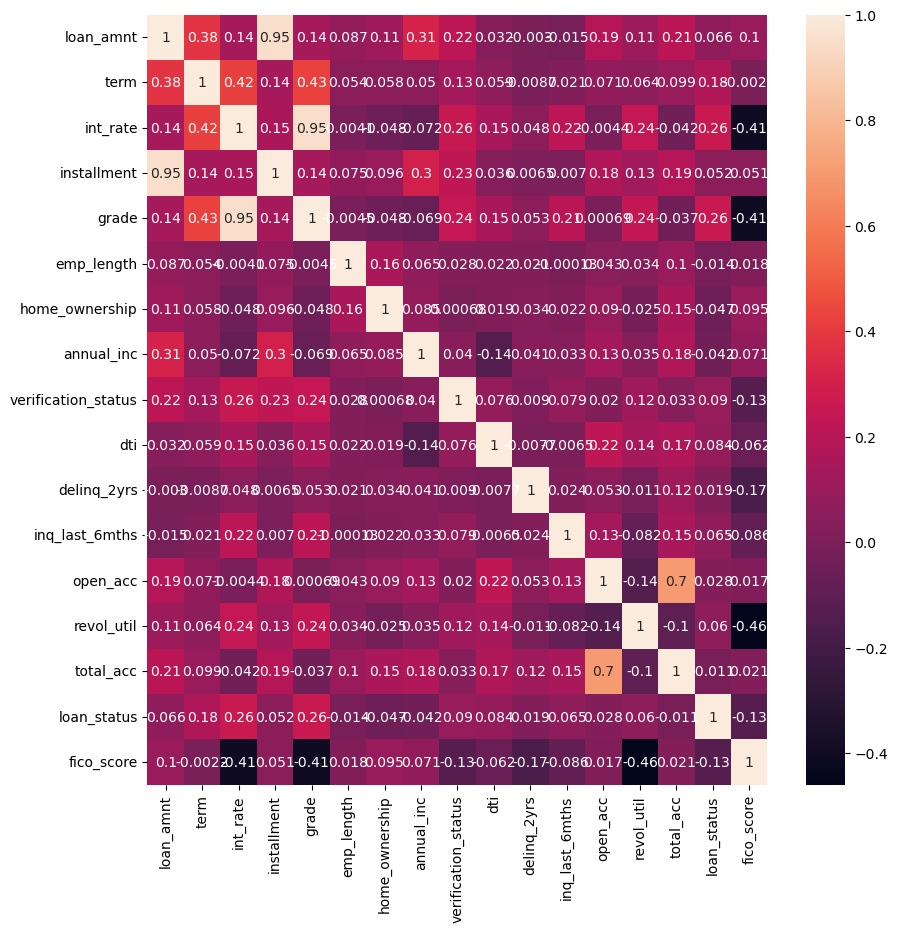

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

sns.heatmap(df_pd.corr(), annot=True)

plt.show()

In [40]:
df_pd = df_pd.drop("installment",axis=1)

In [41]:
df

loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status,fico_score
f64,i32,f64,f64,i32,f64,i32,f64,i32,f64,f64,f64,f64,f64,f64,i32,i32
3600.0,36,13.99,123.03,3,10.0,1,55000.0,0,5.91,0.0,1.0,7.0,29.7,13.0,0,677
24700.0,36,11.99,820.28,3,10.0,1,65000.0,0,16.06,1.0,4.0,22.0,19.2,38.0,0,717
20000.0,60,10.78,432.66,2,10.0,1,63000.0,0,10.78,0.0,0.0,6.0,56.2,18.0,0,697
10400.0,60,22.45,289.91,6,3.0,1,104433.0,1,25.37,1.0,3.0,12.0,64.5,35.0,0,697
11950.0,36,13.44,405.18,3,4.0,0,34000.0,1,10.2,0.0,0.0,5.0,68.4,6.0,0,692
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
18000.0,60,9.49,377.95,2,5.0,2,130000.0,0,20.59,0.0,1.0,17.0,34.0,39.0,0,737
29400.0,60,13.99,683.94,3,9.0,1,180792.0,0,22.03,0.0,1.0,16.0,85.2,32.0,0,707
32000.0,60,14.49,752.74,3,3.0,1,157000.0,1,10.34,0.0,0.0,14.0,27.4,18.0,1,737


In [42]:
from sklearn.model_selection import train_test_split

X = df_pd.drop("loan_status",axis=1)
y = df_pd["loan_status"]

X_train,X_test,y_train,y_test = train_test_split(

X,y,
test_size=0.2,
random_state=42,
stratify=y

)

In [43]:
print(y_train.value_counts(normalize=True))

loan_status
0    0.800374
1    0.199626
Name: proportion, dtype: float64


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.5,  # Good balance
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

C:\Users\cheen\.conda\envs\hat\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [46]:
print(y_train_sm.value_counts())

loan_status
0    861401
1    430700
Name: count, dtype: int64


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train_sm, y_train_sm)

C:\Users\cheen\.conda\envs\hat\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [48]:
pred = model.predict(X_test)

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86    215350
           1       0.39      0.27      0.32     53712

    accuracy                           0.77    269062
   macro avg       0.61      0.58      0.59    269062
weighted avg       0.74      0.77      0.75    269062



In [50]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.6752055632257317


In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)

X_train_sm_original, y_train_sm = smote.fit_resample(X_train,y_train)

C:\Users\cheen\.conda\envs\hat\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

n_estimators=200,
max_depth=10,
random_state=42,
n_jobs=-1

)

rf.fit(X_train_sm_original,y_train_sm)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [53]:
probs_rf = rf.predict_proba(X_test)[:,1]

In [54]:
from sklearn.metrics import roc_auc_score

probs_rf = rf.predict_proba(X_test)[:,1]

print("ROC-AUC:",roc_auc_score(y_test,probs_rf))

ROC-AUC: 0.6990201483646513


In [55]:
from sklearn.metrics import classification_report

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88    215350
           1       0.46      0.14      0.21     53712

    accuracy                           0.80    269062
   macro avg       0.64      0.55      0.55    269062
weighted avg       0.74      0.80      0.75    269062



In [60]:
df.shape

(1345310, 17)

In [63]:
df.write_csv("preprocessed_data.csv")

In [64]:
import polars as pl

test_df = pl.read_csv("preprocessed_data.csv")
print(test_df.shape)

(1345310, 17)


In [65]:
df_pd = df.to_pandas()

In [69]:
df_pd.to_csv('preprocessed_data.csv',index=False)

In [70]:
df2=pd.read_csv('preprocessed_data.csv')

In [71]:
df2

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,loan_status,fico_score
0,3600.0,36,13.99,123.03,3,10.0,1,55000.0,0,5.91,0.0,1.0,7.0,29.7,13.0,0,677
1,24700.0,36,11.99,820.28,3,10.0,1,65000.0,0,16.06,1.0,4.0,22.0,19.2,38.0,0,717
2,20000.0,60,10.78,432.66,2,10.0,1,63000.0,0,10.78,0.0,0.0,6.0,56.2,18.0,0,697
3,10400.0,60,22.45,289.91,6,3.0,1,104433.0,1,25.37,1.0,3.0,12.0,64.5,35.0,0,697
4,11950.0,36,13.44,405.18,3,4.0,0,34000.0,1,10.20,0.0,0.0,5.0,68.4,6.0,0,692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345305,18000.0,60,9.49,377.95,2,5.0,2,130000.0,0,20.59,0.0,1.0,17.0,34.0,39.0,0,737
1345306,29400.0,60,13.99,683.94,3,9.0,1,180792.0,0,22.03,0.0,1.0,16.0,85.2,32.0,0,707
1345307,32000.0,60,14.49,752.74,3,3.0,1,157000.0,1,10.34,0.0,0.0,14.0,27.4,18.0,1,737
1345308,16000.0,60,12.79,362.34,3,10.0,0,150000.0,0,12.25,0.0,0.0,12.0,55.0,28.0,0,667
